# Actividad 5 — Autocorrelación Espacial Local
## Elecciones presidenciales Chile 2025 — Región Metropolitana

En esta actividad aplicarás los **estadísticos locales** del I de Moran ($I_i$) y del G de Getis-Ord ($G_i^*$) a los resultados de la **segunda vuelta presidencial de 2025** en las comunas de la **Región Metropolitana**.

El objetivo es identificar:

- **Hot spots** (concentraciones de voto Kast) y **cold spots** (concentraciones de voto Jara),
- **Outliers espaciales**: comunas que votan distinto a su entorno,

## Instrucciones

1. Ejecuta primero las celdas de **Setup** (cargan datos y construyen la cartografía).
2. Luego resuelve cada ejercicio en las celdas marcadas con `# Tu código aquí`.
3. Responde las preguntas de interpretación directamente en celdas markdown (cuando aplique).

## Setup — Carga de datos y matriz de pesos

Ejecuta estas celdas **sin modificarlas**.

In [54]:
# Gráficos
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import seaborn
import contextily

# Análisis espacial
import geopandas
import pandas
import numpy as np
import esda
from esda.moran import Moran, Moran_Local
from esda.getisord import G_Local
from libpysal import weights
from numpy.random import seed

# Visualización específica LISA
import splot
from splot.esda import plot_moran, lisa_cluster, plot_local_autocorrelation

In [55]:
# Cargar resultados electorales de la segunda vuelta 2025 (RM)
elec = pandas.read_csv("/content/resultados_2v_rm.csv")

# Cargar geometrías de comunas de la RM (Censo 2017)
comunas = geopandas.read_file("/content/COMUNA_C17.shp")

# Unir datos electorales con geometrías y reproyectar a Web Mercator
db = comunas.merge(elec, on="NOM_COMUNA", how="inner")
db = db.to_crs(epsg=3857)

print(f"Comunas con datos: {len(db)}")
db[["NOM_COMUNA", "Pct_Kast", "Pct_Jara", "Ganador"]].head()

Comunas con datos: 52


,NOM_COMUNA,Pct_Kast,Pct_Jara,Ganador
0,PAINE,58.9,41.1,Kast
1,BUIN,58.4,41.6,Kast
2,PUDAHUEL,48.6,51.4,Jara
3,CERRO NAVIA,42.3,57.7,Jara
4,COLINA,57.6,42.4,Kast


In [56]:
# Matriz de pesos espaciales (k-vecinos más cercanos, k=5)
w = weights.KNN.from_dataframe(db, k=5)
w.transform = "R"   # estandarización por filas

---
## Ejercicio 1 — I de Moran local sobre Pct_Kast (20 min)

Vamos a calcular el **I de Moran local** ($I_i$) para el porcentaje de voto Kast en cada comuna. Recuerda que cada $I_i$ clasifica la comuna en uno de cuatro cuadrantes del gráfico de Moran:

| Código | Cuadrante | Significado |
|:------:|:---------:|:------------|
| 1 | HH | alto Kast rodeado de alto Kast (*hot spot*) |
| 2 | LH | bajo Kast rodeado de alto Kast (*doughnut*) |
| 3 | LL | bajo Kast rodeado de bajo Kast (*cold spot*) |
| 4 | HL | alto Kast rodeado de bajo Kast (*diamond*) |

**1.1** Calcula el **I de Moran local** para cada comuna

In [57]:
# Tu código aquí
lisa = Moran_Local(db['Pct_Kast'], w)
lisa

**1.2** Guarda en `db` tres columnas nuevas con los atributos principales del objeto `lisa`:
- `Ii` ← (valor del $I_i$ local)
- `q_cuadrante` ← (cuadrante: 1=HH, 2=LH, 3=LL, 4=HL)
- `p_sim` ←  (pseudo p-valor)

In [58]:
# Tu código aquí
db['Ii'] = lisa.Is
db['q_cuadrante'] = lisa.q
db['p_sim'] = lisa.p_sim

**1.3** Construye una columna `spots` que codifique la clasificación final: si el área NO es significativa ($p \geq 0.05$), debe valer 0; si es significativa, debe conservar el código de cuadrante.

Luego crea una columna con los spots labels, "No significativo","HH","LH", "LL","HL".


Finalmente imprime el conteo de cada categoría.

In [69]:
# Tu código aquí
db['spots'] = np.where(db['p_sim'] >= 0.05, 0, db['q_cuadrante'])
db['labels'] = np.where(db['spots'] == 1, "HH (hot spot)", np.where(db['spots'] == 2, "LH (doughnut)", np.where(db['spots'] == 3, "LL (cold spot)", np.where(db['spots'] == 4, "HL Diamond", "No significativo"))))

**1.4** Crea un **mapa LISA** considerando un `p=0.05` (umbral de significancia). Agrega un título descriptivo.

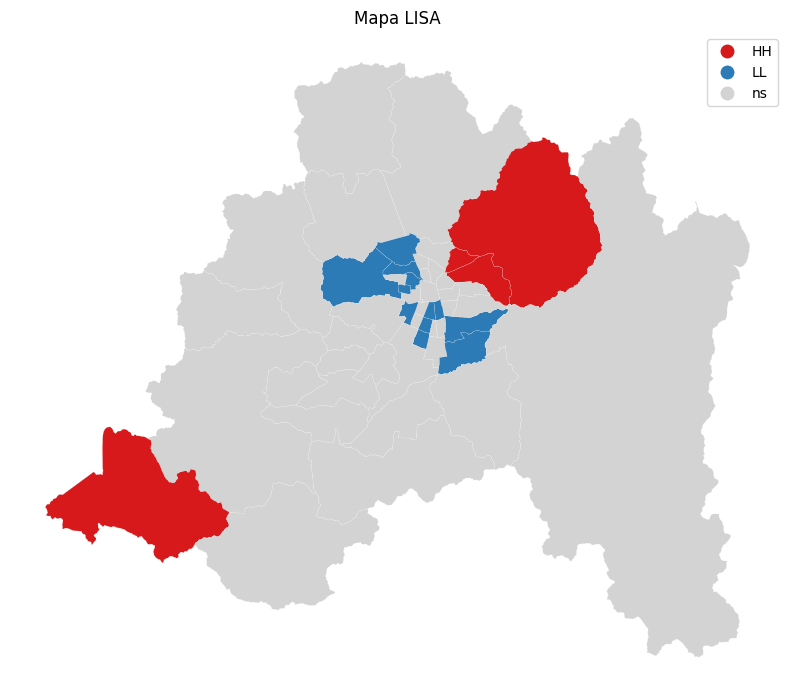

In [60]:
# Tu código aquí
f, ax = plt.subplots(1, figsize=(10, 10))
lisa_cluster(lisa, db, p=0.05, ax=ax)
ax.set_axis_off()
ax.set_title("Mapa LISA")
plt.show()

**1.5** Identifica **las comunas HH**  (Kast lovers) y **las comunas LL** (Jara lovers Jara).

In [71]:
# Tu código aquí
print("Las comunas donde ganó Kast ganó por mucho")
db[['NOM_COMUNA', 'labels']][db['labels'] == "HH (hot spot)"]

Las comunas donde ganó Kast ganó por mucho


,NOM_COMUNA,labels
22,LAS CONDES,HH (hot spot)
24,LO BARNECHEA,HH (hot spot)
25,VITACURA,HH (hot spot)
50,SAN PEDRO,HH (hot spot)


In [72]:
print("Las comunas donde ganó Jara o Kast ganó por poco")
db[['NOM_COMUNA', 'labels']][db['labels'] == "LL (cold spot)"]

Las comunas donde ganó Jara o Kast ganó por poco


,NOM_COMUNA,labels
2,PUDAHUEL,LL (cold spot)
12,EL BOSQUE,LL (cold spot)
19,LA CISTERNA,LL (cold spot)
20,LA FLORIDA,LL (cold spot)
26,QUINTA NORMAL,LL (cold spot)
27,LO PRADO,LL (cold spot)
28,CERRILLOS,LL (cold spot)
35,PUENTE ALTO,LL (cold spot)
36,QUILICURA,LL (cold spot)
37,RENCA,LL (cold spot)


**1.6 — Interpretación.** Responde en una celda markdown:

- ¿Qué comunas forman los son Kast lovers? ¿Se agrupan geográficamente en alguna zona específica de Santiago?
- ¿Qué comunas forman los Jara lovers? ¿En qué sector de la ciudad están?

*(Escribe tu respuesta aquí)*

Las comunas que forman los Kast Lovers son Las Condes, San Pedro, Lo Barnechea, Vitacura, se agrupan en la zona nor-oriente de Santiago. Y un excepcional al sur-poniente (San Pedro).

Las comunas que forman los Jara Lovers son diversas pero están concentradas en la zona centro-poniente (Lo Prado, Pudahuel, etc) y la zona sur (Puente Alto, La Florida, etc) de Santiago.


---
## Ejercicio 2 — Outliers espaciales (15 min)

Los outliers espaciales son comunas que **votan distinto a sus vecinas**. En el I de Moran local aparecen como:

- **LH** (*doughnut*): bajo Kast rodeado de alto Kast — una isla Jara en territorio Kast.
- **HL** (*diamond*): alto Kast rodeado de bajo Kast — una isla Kast en territorio Jara.

**2.1** Lista todas las comunas clasificadas como **LH** y **HL** (outliers). Muestra `NOM_COMUNA`, `Pct_Kast` y el cuadrante.

In [76]:
# Tu código aquí
db[['NOM_COMUNA', 'Pct_Kast', 'q_cuadrante']][db['labels'] == "LH (doughnut)"]

,NOM_COMUNA,Pct_Kast,q_cuadrante


In [77]:
db[['NOM_COMUNA', 'Pct_Kast', 'q_cuadrante']][db['labels'] == "HL Diamond"]

,NOM_COMUNA,Pct_Kast,q_cuadrante


No hay ninguna comuna en LH ni en HL

---
## Ejercicio 3 — Getis-Ord local $G_i^*$ (20 min)

El $G_i^*$ es el estadístico estándar para *hot spot analysis*. A diferencia del I de Moran local, **no distingue outliers** — solo clasifica en hot / cold / no-significativo.

La clasificación se hace con el **z-score** y el **p-valor**:

| Condición | Clasificación |
|:---:|:---:|
| $z > 0$ y $p < 0.05$ | Hot spot |
| $z < 0$ y $p < 0.05$ | Cold spot |
| $p \geq 0.05$ | No significativo |

**3.1** Calcula el $G_i^*$ local con `G_Local(db["Pct_Kast"], w)`.

In [79]:
# Tu código aquí
go_i = G_Local(db["Pct_Kast"], w, star=False)

go_i_star = G_Local(db["Pct_Kast"], w, star=True)


/usr/local/lib/python3.12/dist-packages/esda/getisord.py:421: UserWarning: Gi* requested, but (a) weights are already row-standardized, (b) no weights are on the diagonal, and (c) no default value supplied to star. Assuming that the self-weight is equivalent to the maximum weight in the row. To use a different default (like, .5), set `star=.5`, or use libpysal.weights.fill_diagonal() to set the diagonal values of your weights matrix and use `star=None` in Gi_Local.
  w, star = _infer_star_and_structure_w(w, star, transform)


**3.2** Guarda el **z-score** y el **p-valor** en las columnas `Gistar_z` y `Gistar_p` de `db`.

In [80]:
db['Gistar_z'] = go_i_star.Zs
db['Gistar_p'] = go_i_star.p_sim

db['Gistar_z'] = go_i_star.Zs
db['Gistar_p'] = go_i_star.p_sim

**3.3** Clasifica cada comuna como *Hot spot*, *Cold spot* o *No significativo* siguiendo la regla de la tabla. Guarda el resultado en la columna `Gistar_cat`. Imprime el conteo.

In [82]:
# Tu código aquí
db['Gistar_cat']= "No significativoo"

hot  = (db['Gistar_p'] < 0.05) & (db['Gistar_z'] > 0)
db.loc[hot, 'Gistar_cat'] = 'Hot spot'

cold = (db['Gistar_p'] < 0.05) & (db['Gistar_z'] < 0)
db.loc[cold, 'Gistar_cat'] = 'Cold spot'

db['Gistar_cat'].value_counts()

,count
Gistar_cat,
No significativoo,33
Cold spot,15
Hot spot,4


**3.4** Dibuja un **mapa de hot/cold spots** Agrega leyenda y título descriptivo.

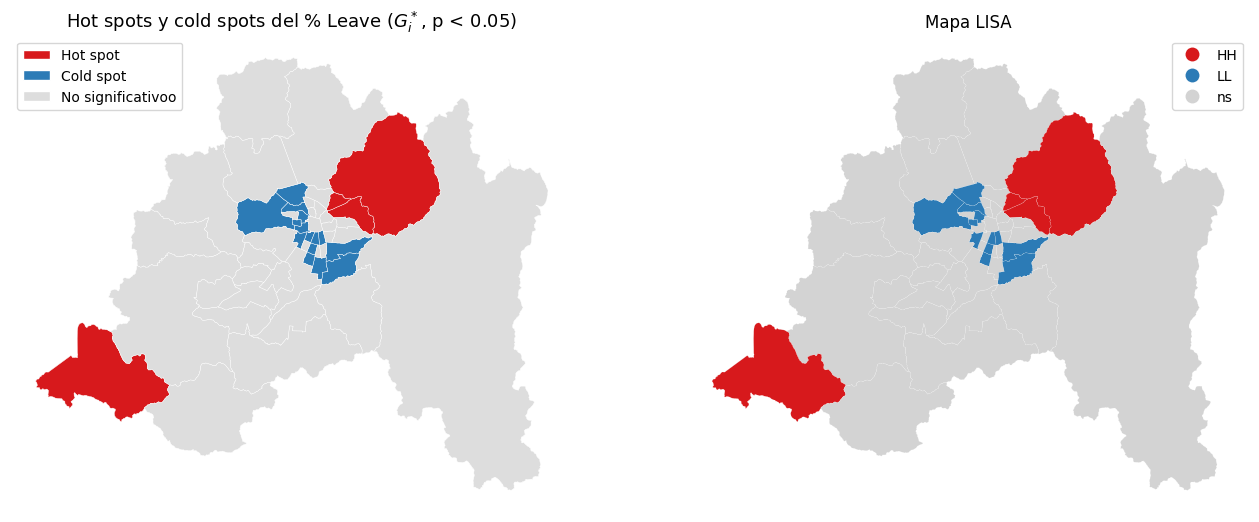

In [92]:
# Tu código aquí
colores_gi = {
    "Hot spot":         "#d7191c",
    "Cold spot":        "#2c7bb6",
    "No significativoo": "#dddddd",
}

f, ax = plt.subplots(1, 2, figsize=(16, 10))
for cat, color in colores_gi.items():
    sub = db[db["Gistar_cat"] == cat]
    if len(sub):
        sub.plot(ax=ax[0], color=color, edgecolor="white", linewidth=0.3)

handles = [Patch(facecolor=c, edgecolor="white", label=l)
           for l, c in colores_gi.items()]
ax[0].legend(handles=handles, loc="upper left", frameon=True, fontsize=10)
ax[0].set_title("Hot spots y cold spots del % Leave ($G_i^*$, p < 0.05)",
             fontsize=13)
ax[0].set_axis_off()

# Tu código aquí
lisa_cluster(lisa, db, p=0.05, ax=ax[1])
ax[1].set_axis_off()
ax[1].set_title("Mapa LISA")
plt.show()

**3.5 — Comparación.** Pon lado a lado el **mapa LISA** del Ejercicio 1 y el **mapa Gi\*** de este ejercicio. ¿Dónde coinciden? ¿Dónde difieren? ¿Qué áreas desaparecen en el mapa Gi\* que sí estaban en el LISA?

*(Escribe tu respuesta aquí)*

Los mapas coinciden en la mayoria de comunas, sin embargo hay algunas que pasan de "no significativo" a "Jara lovers": La Pintana, Pedro aguirre cerda, Estación central.
En todas las demás coinciden.